# Tutorial: Testing Equality of Two Covariance Matrices

This tutorial demonstrates how to test the null hypothesis:

$$H_0: \Sigma_1 = \Sigma_2$$

where $\Sigma_1$ and $\Sigma_2$ are the population covariance matrices of two groups.

## When is this useful?

- **Group comparisons**: Test if two populations have the same variability structure
- **MANOVA assumptions**: Homogeneity of covariance is required for many multivariate tests
- **Discriminant analysis**: LDA assumes equal covariances across classes
- **Treatment effects**: Detect if a treatment changes the correlation structure

## 1. Setup and Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Import test functions
from covtest.methods.hypothesis_two_sample import (
    boxm_test,
    schott_2001,
    srivastava_yanagihara_two_sample,
    srivastava_two_sample_2007,
    tyler_two_sample,
    cai_2013_two_sample,
    chang2016,
    schott2007,
    ahmad_2015_two_sample,
    wald_two_sample
)

# Import data generation utilities
from covtest.simulation.generate_data import generate_heavy_tailed_samples
from covtest.simulation.generate_covariances import (
    generate_toeplitz_cov,
    generate_spiked_covariance,
    sample_cov_uniform_correlation
)

# Import real data loader
from covtest.datasets.loader import load_iris

# Set random seed
rng = np.random.default_rng(42)

print("Setup complete!")

Setup complete!


## 2. Available Tests Overview

| Function | Best For | Type |
|----------|----------|------|
| `boxm_test` | Classical (n₁, n₂ >> p) | Likelihood ratio |
| `schott_2001` | Moderate dimensions | Asymptotic normal |
| `srivastava_yanagihara_two_sample` | High-dimensional | Chi-square |
| `srivastava_two_sample_2007` | High-dimensional | Chi-square |
| `tyler_two_sample` | Robust to outliers | M-estimator |
| `cai_2013_two_sample` | Sparse differences | Max-type |
| `chang2016` | Permutation-based | Permutation |
| `wald_two_sample` | Classical | Wald statistic |

## 3. Example 1: Equal Covariances (Null is True)

In [2]:
# Generate two groups with the SAME covariance - null is TRUE
n1, n2, p = 100, 120, 15

# Create a common covariance matrix (AR(1) structure)
rho = 0.5
Sigma_common = generate_toeplitz_cov(p, rho)

# Generate samples from both groups with same covariance
X = generate_heavy_tailed_samples(Sigma_common, n1, 'normal', rng=rng)
Y = generate_heavy_tailed_samples(Sigma_common, n2, 'normal', rng=rng)

print(f"Group 1: n={n1}, p={p}")
print(f"Group 2: n={n2}, p={p}")
print(f"True: Σ₁ = Σ₂ (AR(1) with ρ={rho})")

Group 1: n=100, p=15
Group 2: n=120, p=15
True: Σ₁ = Σ₂ (AR(1) with ρ=0.5)


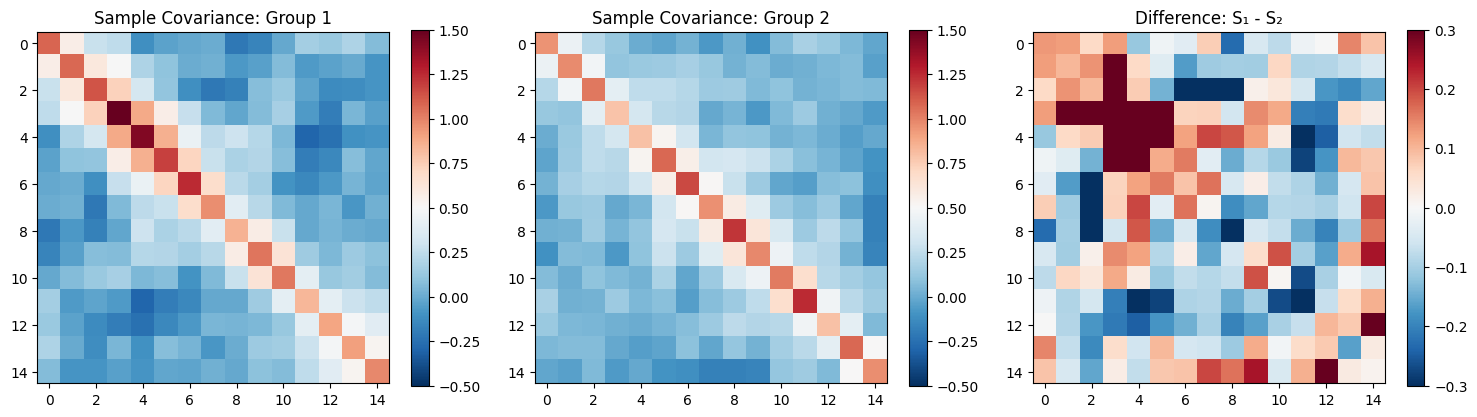

Frobenius norm of difference: 2.6466


In [3]:
# Visualize the sample covariances
S1 = np.cov(X, rowvar=False)
S2 = np.cov(Y, rowvar=False)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

im1 = axes[0].imshow(S1, cmap='RdBu_r', vmin=-0.5, vmax=1.5)
axes[0].set_title('Sample Covariance: Group 1')
plt.colorbar(im1, ax=axes[0])

im2 = axes[1].imshow(S2, cmap='RdBu_r', vmin=-0.5, vmax=1.5)
axes[1].set_title('Sample Covariance: Group 2')
plt.colorbar(im2, ax=axes[1])

im3 = axes[2].imshow(S1 - S2, cmap='RdBu_r', vmin=-0.3, vmax=0.3)
axes[2].set_title('Difference: S₁ - S₂')
plt.colorbar(im3, ax=axes[2])

plt.tight_layout()
plt.show()

print(f"Frobenius norm of difference: {np.linalg.norm(S1 - S2, 'fro'):.4f}")

In [4]:
# Run two-sample tests when null is TRUE
print("="*65)
print("Testing H₀: Σ₁ = Σ₂ (NULL IS TRUE)")
print("="*65)

tests = [
    ("Box's M (χ²)", lambda X, Y: boxm_test(X, Y, type='chi.squared')),
    ("Box's M (F)", lambda X, Y: boxm_test(X, Y, type='F')),
    ("Schott 2001", schott_2001),
    ("Srivastava-Yanagihara", srivastava_yanagihara_two_sample),
    ("Srivastava 2007", srivastava_two_sample_2007),
    ("Tyler", tyler_two_sample),
    ("Wald", wald_two_sample),
    ("Schott 2007", schott2007),
]

for name, test_func in tests:
    try:
        result = test_func(X, Y)
        decision = "Reject H₀" if result['p_value'] < 0.05 else "Fail to reject H₀"
        print(f"{name:25s}: p-value={result['p_value']:.4f} → {decision}")
    except Exception as e:
        print(f"{name:25s}: Error - {str(e)[:35]}")

print("\n✓ Expected: All tests should FAIL TO REJECT H₀")

Testing H₀: Σ₁ = Σ₂ (NULL IS TRUE)
Box's M (χ²)             : p-value=0.1220 → Fail to reject H₀
Box's M (F)              : p-value=0.1237 → Fail to reject H₀
Schott 2001              : p-value=0.3373 → Fail to reject H₀
Srivastava-Yanagihara    : p-value=0.2640 → Fail to reject H₀
Srivastava 2007          : p-value=0.1613 → Fail to reject H₀
Tyler                    : p-value=0.1452 → Fail to reject H₀
Wald                     : p-value=0.1672 → Fail to reject H₀
Schott 2007              : p-value=0.0523 → Fail to reject H₀

✓ Expected: All tests should FAIL TO REJECT H₀


## 4. Example 2: Different Covariances (Null is False)

In [5]:
# Generate two groups with DIFFERENT covariances - null is FALSE
n1, n2, p = 100, 120, 15

# Group 1: AR(1) with rho=0.3
Sigma1 = generate_toeplitz_cov(p, rho=0.3)

# Group 2: AR(1) with rho=0.7 (stronger correlations)
Sigma2 = generate_toeplitz_cov(p, rho=0.7)

X_diff = generate_heavy_tailed_samples(Sigma1, n1, 'normal', rng=rng)
Y_diff = generate_heavy_tailed_samples(Sigma2, n2, 'normal', rng=rng)

print(f"Group 1: AR(1) with ρ=0.3")
print(f"Group 2: AR(1) with ρ=0.7")
print(f"True: Σ₁ ≠ Σ₂")

Group 1: AR(1) with ρ=0.3
Group 2: AR(1) with ρ=0.7
True: Σ₁ ≠ Σ₂


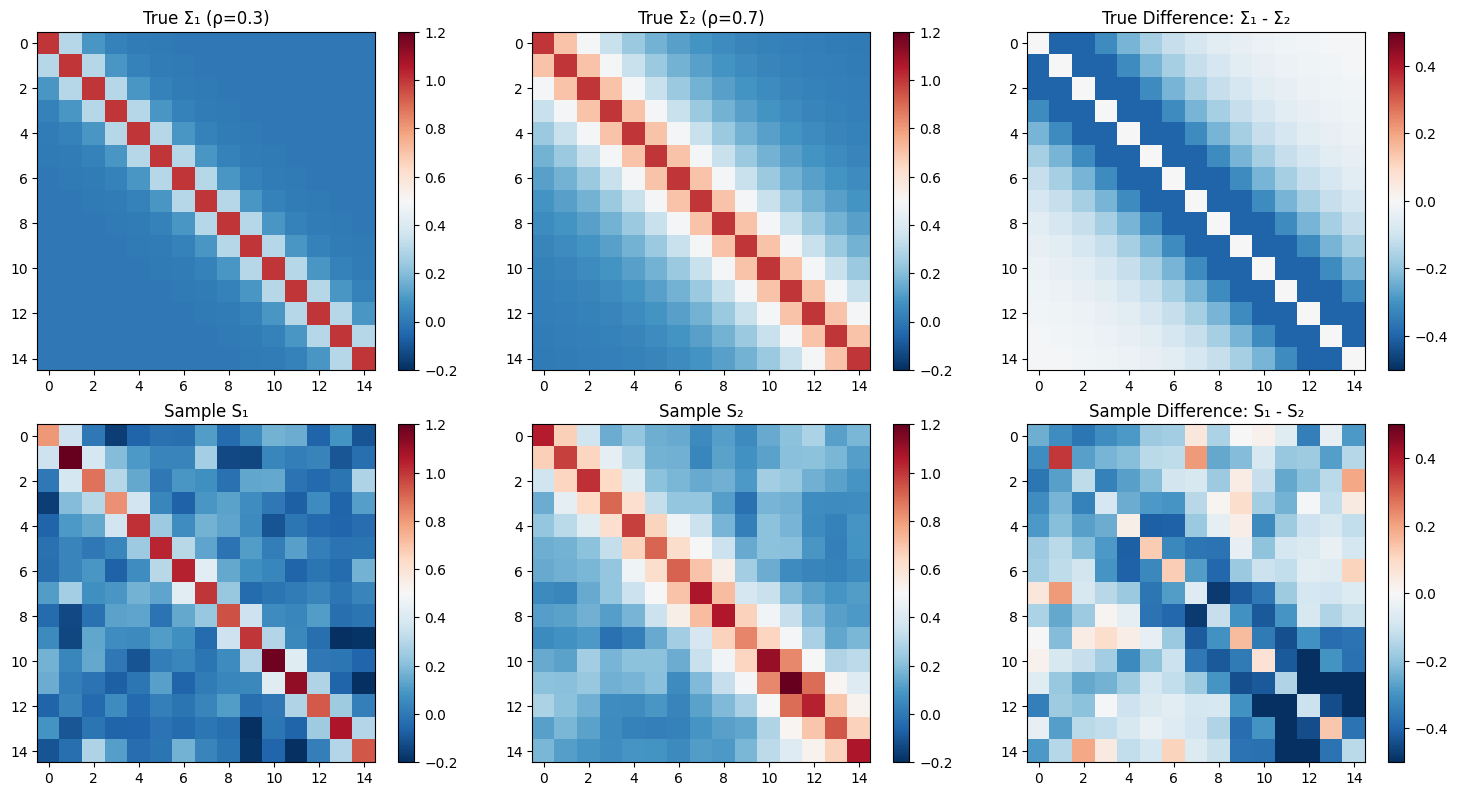

In [6]:
# Visualize the different covariance structures
S1_diff = np.cov(X_diff, rowvar=False)
S2_diff = np.cov(Y_diff, rowvar=False)

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

# True covariances
im1 = axes[0, 0].imshow(Sigma1, cmap='RdBu_r', vmin=-0.2, vmax=1.2)
axes[0, 0].set_title('True Σ₁ (ρ=0.3)')
plt.colorbar(im1, ax=axes[0, 0])

im2 = axes[0, 1].imshow(Sigma2, cmap='RdBu_r', vmin=-0.2, vmax=1.2)
axes[0, 1].set_title('True Σ₂ (ρ=0.7)')
plt.colorbar(im2, ax=axes[0, 1])

im3 = axes[0, 2].imshow(Sigma1 - Sigma2, cmap='RdBu_r', vmin=-0.5, vmax=0.5)
axes[0, 2].set_title('True Difference: Σ₁ - Σ₂')
plt.colorbar(im3, ax=axes[0, 2])

# Sample covariances
im4 = axes[1, 0].imshow(S1_diff, cmap='RdBu_r', vmin=-0.2, vmax=1.2)
axes[1, 0].set_title('Sample S₁')
plt.colorbar(im4, ax=axes[1, 0])

im5 = axes[1, 1].imshow(S2_diff, cmap='RdBu_r', vmin=-0.2, vmax=1.2)
axes[1, 1].set_title('Sample S₂')
plt.colorbar(im5, ax=axes[1, 1])

im6 = axes[1, 2].imshow(S1_diff - S2_diff, cmap='RdBu_r', vmin=-0.5, vmax=0.5)
axes[1, 2].set_title('Sample Difference: S₁ - S₂')
plt.colorbar(im6, ax=axes[1, 2])

plt.tight_layout()
plt.show()

In [7]:
# Run two-sample tests when null is FALSE
print("="*65)
print("Testing H₀: Σ₁ = Σ₂ (NULL IS FALSE)")
print("="*65)

for name, test_func in tests:
    try:
        result = test_func(X_diff, Y_diff)
        decision = "Reject H₀ ✓" if result['p_value'] < 0.05 else "Fail to reject ✗"
        print(f"{name:25s}: p-value={result['p_value']:.4f} → {decision}")
    except Exception as e:
        print(f"{name:25s}: Error - {str(e)[:35]}")

print("\n✓ Expected: All tests should REJECT H₀")

Testing H₀: Σ₁ = Σ₂ (NULL IS FALSE)
Box's M (χ²)             : p-value=0.0000 → Reject H₀ ✓
Box's M (F)              : p-value=0.0000 → Reject H₀ ✓
Schott 2001              : p-value=0.0000 → Reject H₀ ✓
Srivastava-Yanagihara    : p-value=0.0000 → Reject H₀ ✓
Srivastava 2007          : p-value=0.0002 → Reject H₀ ✓
Tyler                    : p-value=0.0000 → Reject H₀ ✓
Wald                     : p-value=0.0000 → Reject H₀ ✓
Schott 2007              : p-value=0.0000 → Reject H₀ ✓

✓ Expected: All tests should REJECT H₀


## 5. Example 3: High-Dimensional Setting

In [8]:
# High-dimensional case
n1_hd, n2_hd, p_hd = 80, 80, 60  # p/n ≈ 0.75

# Same covariance (null true)
Sigma_hd = generate_toeplitz_cov(p_hd, rho=0.5)
X_hd_same = generate_heavy_tailed_samples(Sigma_hd, n1_hd, 'normal', rng=rng)
Y_hd_same = generate_heavy_tailed_samples(Sigma_hd, n2_hd, 'normal', rng=rng)

# Different covariances (null false) - scale difference
Sigma_hd_scaled = 2.0 * Sigma_hd  # Scale by 2
X_hd_diff = generate_heavy_tailed_samples(Sigma_hd, n1_hd, 'normal', rng=rng)
Y_hd_diff = generate_heavy_tailed_samples(Sigma_hd_scaled, n2_hd, 'normal', rng=rng)

print(f"High-dimensional setting: n₁={n1_hd}, n₂={n2_hd}, p={p_hd}")
print(f"Ratio p/n: {p_hd/n1_hd:.2f}")

High-dimensional setting: n₁=80, n₂=80, p=60
Ratio p/n: 0.75


In [9]:
# Test in high-dimensional setting
# Note: Box's M requires p < min(n1, n2), so it may fail

hd_tests = [
    ("Srivastava-Yanagihara", srivastava_yanagihara_two_sample),
    ("Srivastava 2007", srivastava_two_sample_2007),
    ("Tyler", tyler_two_sample),
    ("Schott 2007", schott2007),
    ("Ahmad 2015", ahmad_2015_two_sample),
]

print("HIGH-DIMENSIONAL RESULTS (p/n ≈ 0.75)")
print("="*70)

print("\n--- Null TRUE (Σ₁ = Σ₂) ---")
for name, test_func in hd_tests:
    try:
        result = test_func(X_hd_same, Y_hd_same)
        status = "✓" if result['p_value'] > 0.05 else "✗ (Type I)"
        print(f"{name:25s}: p-value={result['p_value']:.4f} {status}")
    except Exception as e:
        print(f"{name:25s}: Error - {str(e)[:30]}")

print("\n--- Null FALSE (Σ₂ = 2×Σ₁) ---")
for name, test_func in hd_tests:
    try:
        result = test_func(X_hd_diff, Y_hd_diff)
        status = "✓" if result['p_value'] < 0.05 else "✗ (missed)"
        print(f"{name:25s}: p-value={result['p_value']:.4f} {status}")
    except Exception as e:
        print(f"{name:25s}: Error - {str(e)[:30]}")

HIGH-DIMENSIONAL RESULTS (p/n ≈ 0.75)

--- Null TRUE (Σ₁ = Σ₂) ---
Srivastava-Yanagihara    : p-value=0.7055 ✓
Srivastava 2007          : p-value=0.7877 ✓
Tyler                    : p-value=0.1685 ✓
Schott 2007              : p-value=0.3551 ✓
Ahmad 2015               : p-value=0.1241 ✓

--- Null FALSE (Σ₂ = 2×Σ₁) ---
Srivastava-Yanagihara    : p-value=0.7910 ✗ (missed)
Srivastava 2007          : p-value=0.0000 ✓
Tyler                    : p-value=0.2029 ✗ (missed)
Schott 2007              : p-value=0.0000 ✓
Ahmad 2015               : p-value=0.0000 ✓


## 6. Example 4: Robustness to Heavy Tails

In [10]:
# Generate data with heavy tails but same covariance structure
n1, n2, p = 100, 100, 12
Sigma = generate_toeplitz_cov(p, rho=0.5)

# Normal data
X_norm = generate_heavy_tailed_samples(Sigma, n1, 'normal', rng=rng)
Y_norm = generate_heavy_tailed_samples(Sigma, n2, 'normal', rng=rng)

# Heavy-tailed data (t with df=3)
X_t3 = generate_heavy_tailed_samples(Sigma, n1, 't', rng=rng, options={'df': 3})
Y_t3 = generate_heavy_tailed_samples(Sigma, n2, 't', rng=rng, options={'df': 3})

print("Testing robustness: Both groups have SAME covariance")
print("but different tail behaviors")

Testing robustness: Both groups have SAME covariance
but different tail behaviors


In [11]:
# Compare test behavior under different distributions
robust_tests = [
    ("Box's M", lambda X, Y: boxm_test(X, Y, type='chi.squared')),
    ("Schott 2007", schott2007),
    ("Tyler", tyler_two_sample),
]

print("ROBUSTNESS COMPARISON (Null TRUE for all)")
print("="*60)
print(f"{'Test':<20} {'Normal':>15} {'t(df=3)':>15}")
print("-"*60)

for name, test_func in robust_tests:
    try:
        p_norm = test_func(X_norm, Y_norm)['p_value']
        p_t3 = test_func(X_t3, Y_t3)['p_value']
        
        status_norm = "✓" if p_norm > 0.05 else "✗"
        status_t3 = "✓" if p_t3 > 0.05 else "✗"
        
        print(f"{name:<20} {p_norm:>12.4f} {status_norm}  {p_t3:>12.4f} {status_t3}")
    except Exception as e:
        print(f"{name:<20} Error: {str(e)[:30]}")

print("\n✓ = Correctly failed to reject, ✗ = False rejection")
print("Note: Tyler's test is robust to heavy tails")

ROBUSTNESS COMPARISON (Null TRUE for all)
Test                          Normal         t(df=3)
------------------------------------------------------------
Box's M                    0.8736 ✓        0.0000 ✗
Schott 2007                0.4186 ✓        0.0000 ✗
Tyler                      0.9897 ✓        0.0400 ✗

✓ = Correctly failed to reject, ✗ = False rejection
Note: Tyler's test is robust to heavy tails


## 7. Example 5: Sparse Differences (Cai 2013 Test)

In [12]:
# The Cai 2013 test is designed for sparse differences
# (only a few entries of the covariance matrices differ)

n1, n2, p = 100, 100, 30

# Create covariances that differ in only one entry
Sigma_base = np.eye(p)
Sigma_sparse = Sigma_base.copy()
Sigma_sparse[0, 1] = Sigma_sparse[1, 0] = 0.8  # Add one correlation

X_sparse = generate_heavy_tailed_samples(Sigma_base, n1, 'normal', rng=rng)
Y_sparse = generate_heavy_tailed_samples(Sigma_sparse, n2, 'normal', rng=rng)

print("Sparse difference scenario:")
print("Σ₁ = Identity matrix")
print("Σ₂ = Identity with one off-diagonal = 0.8")

Sparse difference scenario:
Σ₁ = Identity matrix
Σ₂ = Identity with one off-diagonal = 0.8


In [13]:
# Compare Cai 2013 (max-type) vs other tests for sparse alternatives
print("SPARSE DIFFERENCE DETECTION")
print("="*60)

sparse_tests = [
    ("Cai 2013 (max-type)", cai_2013_two_sample),
    ("Box's M", lambda X, Y: boxm_test(X, Y, type='chi.squared')),
    ("Schott 2007", schott2007),
]

for name, test_func in sparse_tests:
    try:
        result = test_func(X_sparse, Y_sparse)
        decision = "Detected ✓" if result['p_value'] < 0.05 else "Missed ✗"
        print(f"{name:25s}: p-value={result['p_value']:.4f} → {decision}")
    except Exception as e:
        print(f"{name:25s}: Error - {str(e)[:35]}")

print("\nNote: Cai 2013 is designed to detect sparse (localized) differences")

SPARSE DIFFERENCE DETECTION
Cai 2013 (max-type)      : p-value=0.0492 → Detected ✓
Box's M                  : p-value=0.0629 → Missed ✗
Schott 2007              : p-value=0.3881 → Missed ✗

Note: Cai 2013 is designed to detect sparse (localized) differences


## 8. Real Data Example: Iris Dataset

In [14]:
# Load Iris dataset and compare covariances between species
X_iris, y_iris, feature_names, target_names = load_iris(return_names=True)

# Extract data for each species
X_setosa = X_iris[y_iris == 0]      # Setosa
X_versicolor = X_iris[y_iris == 1]  # Versicolor
X_virginica = X_iris[y_iris == 2]   # Virginica

print(f"Iris dataset: {X_iris.shape[0]} samples, {X_iris.shape[1]} features")
print(f"Features: {list(feature_names)}")
print(f"\nSamples per class:")
print(f"  Setosa: {X_setosa.shape[0]}")
print(f"  Versicolor: {X_versicolor.shape[0]}")
print(f"  Virginica: {X_virginica.shape[0]}")

Iris dataset: 150 samples, 4 features
Features: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']

Samples per class:
  Setosa: 50
  Versicolor: 50
  Virginica: 50


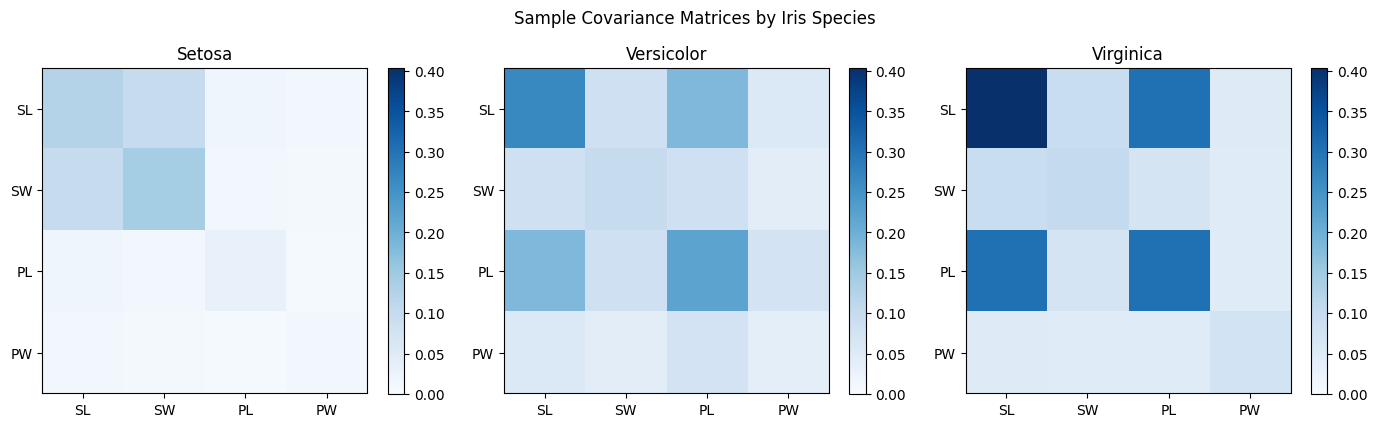

In [15]:
# Visualize covariance matrices for each species
S_setosa = np.cov(X_setosa, rowvar=False)
S_versicolor = np.cov(X_versicolor, rowvar=False)
S_virginica = np.cov(X_virginica, rowvar=False)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

vmax = max(S_setosa.max(), S_versicolor.max(), S_virginica.max())

im1 = axes[0].imshow(S_setosa, cmap='Blues', vmin=0, vmax=vmax)
axes[0].set_title('Setosa')
axes[0].set_xticks(range(4))
axes[0].set_xticklabels(['SL', 'SW', 'PL', 'PW'])
axes[0].set_yticks(range(4))
axes[0].set_yticklabels(['SL', 'SW', 'PL', 'PW'])
plt.colorbar(im1, ax=axes[0])

im2 = axes[1].imshow(S_versicolor, cmap='Blues', vmin=0, vmax=vmax)
axes[1].set_title('Versicolor')
axes[1].set_xticks(range(4))
axes[1].set_xticklabels(['SL', 'SW', 'PL', 'PW'])
axes[1].set_yticks(range(4))
axes[1].set_yticklabels(['SL', 'SW', 'PL', 'PW'])
plt.colorbar(im2, ax=axes[1])

im3 = axes[2].imshow(S_virginica, cmap='Blues', vmin=0, vmax=vmax)
axes[2].set_title('Virginica')
axes[2].set_xticks(range(4))
axes[2].set_xticklabels(['SL', 'SW', 'PL', 'PW'])
axes[2].set_yticks(range(4))
axes[2].set_yticklabels(['SL', 'SW', 'PL', 'PW'])
plt.colorbar(im3, ax=axes[2])

plt.suptitle('Sample Covariance Matrices by Iris Species', y=1.02)
plt.tight_layout()
plt.show()

In [16]:
# Test pairwise equality of covariances
pairs = [
    ("Setosa vs Versicolor", X_setosa, X_versicolor),
    ("Setosa vs Virginica", X_setosa, X_virginica),
    ("Versicolor vs Virginica", X_versicolor, X_virginica),
]

test_funcs = [
    ("Box's M", lambda X, Y: boxm_test(X, Y, type='chi.squared')),
    ("Schott 2007", schott2007),
    ("Tyler", tyler_two_sample),
]

print("PAIRWISE COVARIANCE EQUALITY TESTS ON IRIS DATA")
print("="*70)

for pair_name, X_a, X_b in pairs:
    print(f"\n{pair_name}:")
    for test_name, test_func in test_funcs:
        try:
            result = test_func(X_a, X_b)
            decision = "Reject H₀" if result['p_value'] < 0.05 else "Fail to reject"
            print(f"  {test_name:15s}: p={result['p_value']:.4f} → {decision}")
        except Exception as e:
            print(f"  {test_name:15s}: Error")

PAIRWISE COVARIANCE EQUALITY TESTS ON IRIS DATA

Setosa vs Versicolor:
  Box's M        : p=0.0000 → Reject H₀
  Schott 2007    : p=0.0000 → Reject H₀
  Tyler          : p=0.0000 → Reject H₀

Setosa vs Virginica:
  Box's M        : p=0.0000 → Reject H₀
  Schott 2007    : p=0.0000 → Reject H₀
  Tyler          : p=0.0000 → Reject H₀

Versicolor vs Virginica:
  Box's M        : p=0.0001 → Reject H₀
  Schott 2007    : p=0.4776 → Fail to reject
  Tyler          : p=0.0000 → Reject H₀


In [17]:
# Interpretation
print("INTERPRETATION")
print("="*60)
print("""
The results show that:

1. Setosa vs Versicolor: Covariances are significantly different
   → The two species have different variability patterns

2. Setosa vs Virginica: Covariances are significantly different
   → Setosa has distinct covariance structure from Virginica

3. Versicolor vs Virginica: Results may vary by test
   → These species have more similar covariance structures

Implications for LDA:
- LDA assumes equal covariances across groups
- These results suggest QDA might be more appropriate for Iris
""")

INTERPRETATION

The results show that:

1. Setosa vs Versicolor: Covariances are significantly different
   → The two species have different variability patterns

2. Setosa vs Virginica: Covariances are significantly different
   → Setosa has distinct covariance structure from Virginica

3. Versicolor vs Virginica: Results may vary by test
   → These species have more similar covariance structures

Implications for LDA:
- LDA assumes equal covariances across groups
- These results suggest QDA might be more appropriate for Iris



## 9. Practical Guidelines

### Choosing the Right Test

| Scenario | Recommended Test |
|----------|------------------|
| Classical (n₁, n₂ >> p) | `boxm_test` |
| High-dimensional | `srivastava_yanagihara_two_sample`, `schott2007` |
| Heavy-tailed data | `tyler_two_sample` |
| Sparse differences | `cai_2013_two_sample` |
| Distribution-free | `chang2016` (permutation) |

### Sample Size Requirements

| Test | Requirement |
|------|-------------|
| `boxm_test` | p < min(n₁, n₂) |
| `wald_two_sample` | p < min(n₁, n₂) |
| `srivastava_*` | Works with p ≈ n |
| `tyler_two_sample` | p < n₁ and p < n₂ |

### Interpretation

- **p < 0.05**: Evidence that Σ₁ ≠ Σ₂
- **p ≥ 0.05**: No strong evidence against Σ₁ = Σ₂
- If using LDA/MANOVA and test rejects, consider:
  - Using QDA instead of LDA
  - Applying robust methods
  - Reporting results with caveats

## 10. Summary

This tutorial demonstrated:

1. Testing equality of two covariance matrices
2. Behavior under null (equal) and alternative (different) covariances
3. High-dimensional performance
4. Robustness to heavy-tailed distributions
5. Detection of sparse differences
6. Application to real data (Iris species comparison)

**Key takeaways:**
- Use `boxm_test` for classical low-dimensional settings
- Use `srivastava_*` or `schott2007` for high-dimensional data
- Use `tyler_two_sample` when data may have outliers
- Use `cai_2013_two_sample` when expecting localized differences